# Two-Stage XGBoost v3 — Presentation-Ready

**What's new vs v2:**
1. **Fixed `pedestrian_involved`** — v2 had a broken pedestrian feature (vehicle_type only contains 'PEDESTRIAN' 1× in the whole dataset). v3 derives it from `factor_vehicle_1/2` using the label `PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CONFUSION`, which appears 5,556× and has a 2.1× higher fatality rate (0.55% vs 0.26% baseline). No leakage: factor columns record the cause of the crash, not the outcome.
2. **Borough-level fairness** — Fatality recall is reported per NYC borough at the 70% operating point, flagging any equity gaps in model performance.
3. **False-positive rate framing** — A dedicated section quantifies the screening burden (false positives per true fatality caught) and frames it for Vision Zero policy use.

**Architecture:** Two-stage XGBoost. Stage 1 = binary Fatality detector (`scale_pos_weight≈363`). Stage 2 = No Injury vs. Injury on the non-fatal subset. Operating point selected by Fatality recall target, not F1 maximization.

---
## 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, roc_auc_score
)

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42
CLASS_NAMES  = ['No Injury', 'Injury', 'Fatality']
print(f'XGBoost {xgb.__version__}')

XGBoost 1.7.6


---
## 2. Load, engineer features, split, preprocess

**v3 change:** Added `ped_bike_factor` — a non-leaky pedestrian/cyclist involvement signal derived from `factor_vehicle_1/2`. The vehicle type columns only contain 'PEDESTRIAN' once in the entire dataset (making the old feature useless). The factor columns, by contrast, contain `PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CONFUSION` 5,556 times. This factor encodes the cause listed at crash time, not the injury outcome, so it is safe to use as a predictor.

In [2]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)
df = df.copy()

def month_to_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'fall'

def hour_to_period(h):
    if h < 5:  return 'late_night'
    if h < 10: return 'morning'
    if h < 15: return 'midday'
    if h < 19: return 'evening'
    return 'night'

df['season']      = df['month'].apply(month_to_season)
df['time_of_day'] = df['hour'].apply(hour_to_period)
vt = ['vehicle_type_1', 'vehicle_type_2']
df['bike_involved']       = df[vt].isin(['BIKE','E-BIKE','E-SCOOTER']).any(axis=1).astype(int)
df['motorcycle_involved'] = df[vt].isin(['MOTORCYCLE','MOPED']).any(axis=1).astype(int)
df['unknown_factor']      = df[['factor_vehicle_1','factor_vehicle_2']].isin(['UNSPECIFIED','UNKNOWN']).any(axis=1).astype(int)

TRUCK_LABELS = ['TRUCK','BOX TRUCK','TRACTOR TRUCK DIESEL','TRACTOR TRUCK GASOLINE',
                'FLAT BED','GARBAGE OR REFUSE','DUMP','TANKER','CONCRETE MIXER']
df['truck_involved'] = df[vt].isin(TRUCK_LABELS).any(axis=1).astype(int)
df['num_vehicles']   = df['vehicle_type_1'].notna().astype(int) + df['vehicle_type_2'].notna().astype(int)
dark = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['bike_dark']  = df['bike_involved'] * dark
df['moto_rush']  = df['motorcycle_involved'] * df['is_rush_hour']

# v3: fixed pedestrian/cyclist involvement flag
# PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CONFUSION appears 5,556x in factor columns
# and has a 2.1x higher fatality rate (0.55%) than the dataset average (0.26%).
# This encodes crash cause, not outcome — no leakage.
PED_BIKE_LABEL = 'PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CONFUSION'
df['ped_bike_factor'] = (
    df[['factor_vehicle_1','factor_vehicle_2']]
    .isin([PED_BIKE_LABEL]).any(axis=1).astype(int)
)

df['lat_bin']    = pd.qcut(df['latitude'],  q=5, labels=['lat0','lat1','lat2','lat3','lat4'], duplicates='drop')
df['lon_bin']    = pd.qcut(df['longitude'], q=5, labels=['lon0','lon1','lon2','lon3','lon4'], duplicates='drop')
df['grid_cell']  = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

# Save raw borough for test set BEFORE one-hot encoding (needed for fairness evaluation)
train_mask = df['year'].isin([2022, 2023, 2024])
test_mask  = df['year'] == 2025
borough_test_raw = df.loc[test_mask, 'borough'].reset_index(drop=True)

DROP_COLS = [
    'severity','num_injured','num_killed',
    'number_of_pedestrians_injured','number_of_pedestrians_killed',
    'number_of_cyclist_injured','number_of_cyclist_killed',
    'number_of_motorist_injured','number_of_motorist_killed',
    'collision_id','crash_date','crash_time',
    'on_street_name','cross_street_name','location',
    'zip_code','year','latitude','longitude','lat_bin','lon_bin',
]
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].copy()
y = df['severity'].copy()

X_train_raw, y_train = X[train_mask].copy(), y[train_mask].copy()
X_test_raw,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

def cap_top_n(series, n=12):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), 'OTHER')

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
for col in ['vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']:
    if col in X_train.columns:
        X_train[col] = cap_top_n(X_train[col])
        X_test[col]  = X_test[col].where(X_test[col].isin(X_train[col].unique()), 'OTHER')

CAT_COLS = ['borough','day_of_week','season','time_of_day','grid_cell',
            'vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]
X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
for df_ in [X_train, X_test]:
    for col in df_.select_dtypes(include='category').columns:
        df_[col] = df_[col].astype(float)
X_train = X_train.fillna(0).astype(float)
X_test  = X_test.fillna(0).astype(float)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Train Fatality: {(y_train==2).sum():,}   Test Fatality: {(y_test==2).sum():,}')
print(f'ped_bike_factor in train: {int(X_train["ped_bike_factor"].sum()):,} crashes flagged')

X_train: (291808, 102)   X_test: (85534, 102)
Train Fatality: 801   Test Fatality: 214
ped_bike_factor in train: 3,691 crashes flagged


---
## 3. Stage 1 — Binary Fatality detector

`scale_pos_weight = 363` — the exact inverse-frequency ratio for the binary problem.  
This is the native XGBoost tool for imbalance: it multiplies the gradient for positive (Fatality) samples by 363 at each boosting step.

In [3]:
y_train_s1 = (y_train == 2).astype(int)
y_test_s1  = (y_test  == 2).astype(int)

n_neg = (y_train_s1 == 0).sum()
n_pos = (y_train_s1 == 1).sum()
spw   = n_neg / n_pos
print(f'scale_pos_weight = {spw:.1f}  (each Fatality treated as {spw:.0f} non-fatal samples in the loss)')

S1_PARAMS = dict(
    objective='binary:logistic',
    scale_pos_weight=spw,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

scale_pos_weight = 363.3  (each Fatality treated as 363 non-fatal samples in the loss)


### 3a. Cross-validate Stage 1 at multiple thresholds

CV now reports recall at **three thresholds** so we know what to expect on test before committing.

In [4]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_thresholds = [0.3, 0.5, 0.7]
cv_results = {t: {'recall': [], 'precision': []} for t in cv_thresholds}
cv_aucs = []

for tr_idx, val_idx in cv.split(X_train, y_train_s1):
    X_tr, y_tr   = X_train.iloc[tr_idx], y_train_s1.iloc[tr_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train_s1.iloc[val_idx]

    m = xgb.XGBClassifier(**S1_PARAMS)
    m.fit(X_tr, y_tr, verbose=False)
    proba = m.predict_proba(X_val)[:, 1]
    cv_aucs.append(roc_auc_score(y_val, proba))

    for t in cv_thresholds:
        pred = (proba >= t).astype(int)
        cv_results[t]['recall'].append(recall_score(y_val, pred, zero_division=0))
        cv_results[t]['precision'].append(precision_score(y_val, pred, zero_division=0))

print(f'Stage 1 CV — ROC-AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')
print(f'\n{"Threshold":>10}  {"Fatality Recall":>16}  {"Fatality Precision":>18}')
for t in cv_thresholds:
    r = cv_results[t]['recall']
    p = cv_results[t]['precision']
    print(f'{t:>10.1f}  {np.mean(r):>10.4f} ± {np.std(r):.4f}  {np.mean(p):>12.4f} ± {np.std(p):.4f}')

Stage 1 CV — ROC-AUC: 0.8237 ± 0.0095

 Threshold   Fatality Recall  Fatality Precision
       0.3      0.6704 ± 0.0122        0.0100 ± 0.0001
       0.5      0.4819 ± 0.0204        0.0150 ± 0.0006
       0.7      0.2784 ± 0.0168        0.0240 ± 0.0020


### 3b. Train final Stage 1 model

In [5]:
stage1 = xgb.XGBClassifier(**S1_PARAMS)
stage1.fit(X_train, y_train_s1, verbose=False)

s1_proba = stage1.predict_proba(X_test)[:, 1]  # P(Fatality)

print(f'Test ROC-AUC: {roc_auc_score(y_test_s1, s1_proba):.4f}')
print(f'\nP(Fatality) statistics on test set:')
print(f'  All crashes:  mean={s1_proba.mean():.4f}  median={np.median(s1_proba):.4f}  max={s1_proba.max():.4f}')
print(f'  True fatals:  mean={s1_proba[y_test==2].mean():.4f}  median={np.median(s1_proba[y_test==2]):.4f}')
print(f'  Non-fatals:   mean={s1_proba[y_test!=2].mean():.4f}  median={np.median(s1_proba[y_test!=2]):.4f}')

Test ROC-AUC: 0.8256

P(Fatality) statistics on test set:
  All crashes:  mean=0.1881  median=0.1055  max=0.9836
  True fatals:  mean=0.5125  median=0.5296
  Non-fatals:   mean=0.1873  median=0.1051


### 3c. Probability distribution — what Stage 1 actually learned

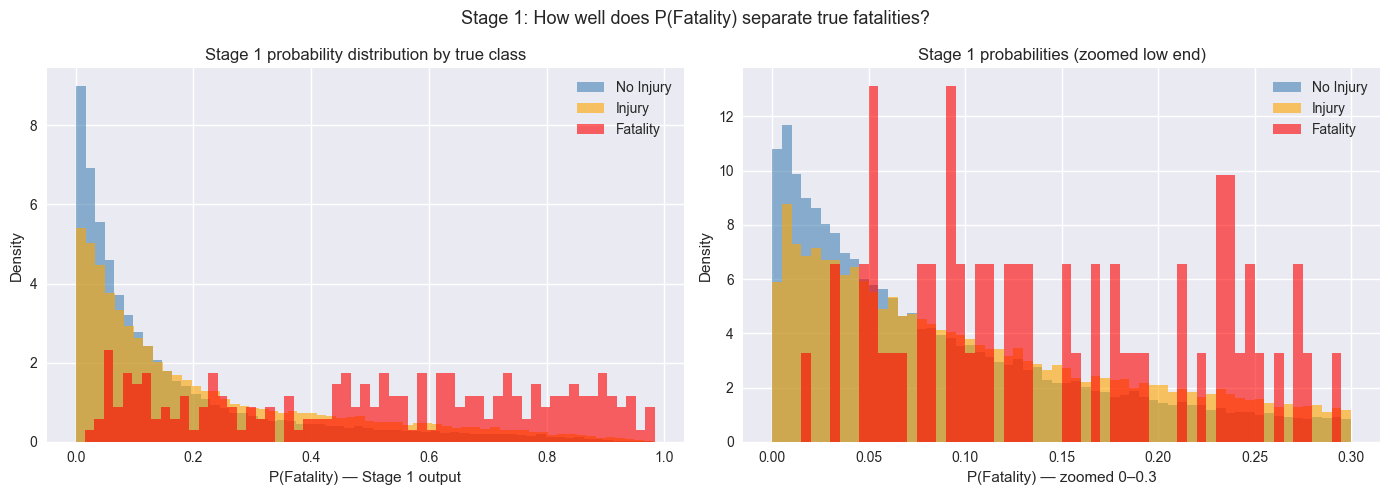

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for cls, name, color in zip([0, 1, 2], CLASS_NAMES, ['steelblue', 'orange', 'red']):
    ax.hist(s1_proba[y_test == cls], bins=60, alpha=0.6, label=name, color=color, density=True)
ax.set_xlabel('P(Fatality) — Stage 1 output')
ax.set_ylabel('Density')
ax.set_title('Stage 1 probability distribution by true class')
ax.legend(); ax.grid(True)

ax = axes[1]
for cls, name, color in zip([0, 1, 2], CLASS_NAMES, ['steelblue', 'orange', 'red']):
    ax.hist(s1_proba[y_test == cls], bins=60, alpha=0.6, label=name, color=color, density=True, range=(0, 0.3))
ax.set_xlabel('P(Fatality) — zoomed 0–0.3')
ax.set_ylabel('Density')
ax.set_title('Stage 1 probabilities (zoomed low end)')
ax.legend(); ax.grid(True)

plt.suptitle('Stage 1: How well does P(Fatality) separate true fatalities?', fontsize=13)
plt.tight_layout(); plt.show()

---
## 4. Stage 2 — No Injury vs. Injury classifier

In [7]:
nonfatal_mask = (y_train != 2).values
X_train_s2    = X_train.iloc[nonfatal_mask]
y_train_s2    = y_train[nonfatal_mask].reset_index(drop=True)

n0, n1 = (y_train_s2 == 0).sum(), (y_train_s2 == 1).sum()
print(f'Stage 2: No Injury={n0:,}  Injury={n1:,}  ratio={n0/n1:.2f}')

S2_PARAMS = dict(
    objective='binary:logistic',
    scale_pos_weight=n0 / n1,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
stage2 = xgb.XGBClassifier(**S2_PARAMS)
stage2.fit(X_train_s2, y_train_s2, verbose=False)
print('Stage 2 training complete.')

Stage 2: No Injury=171,772  Injury=119,235  ratio=1.44


Stage 2 training complete.


---
## 5. Combine stages and full threshold sweep

We sweep the full range 0.01 → 0.99 and evaluate the complete 3-class combined prediction at each point. The goal is to find the operating point that meets a **Fatality recall target**, not to maximize F1.

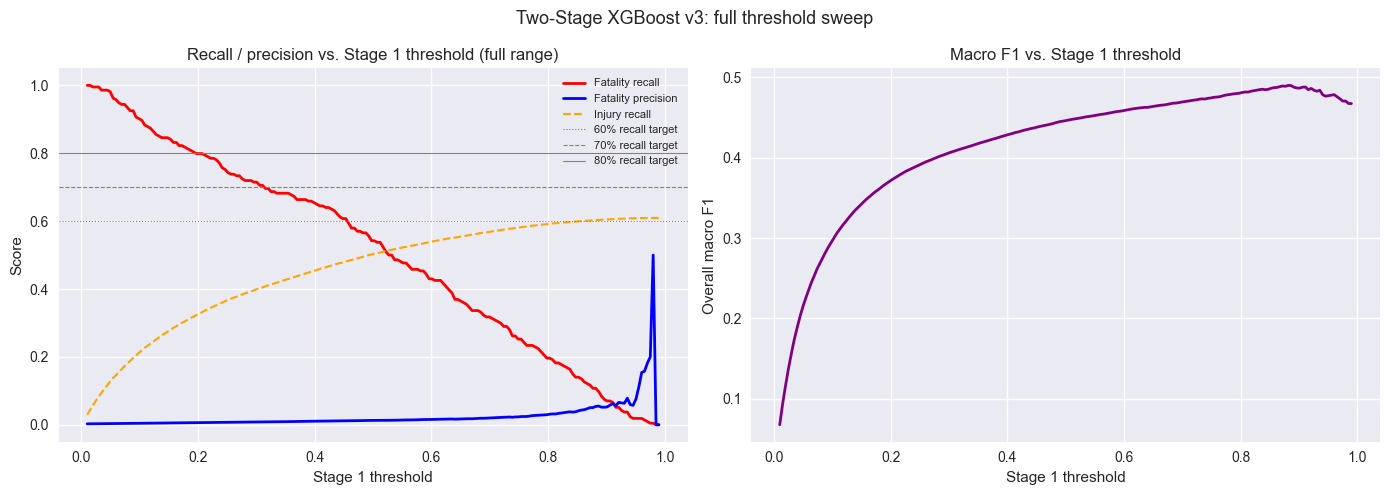

In [8]:
s2_proba   = stage2.predict_proba(X_test)[:, 1]   # P(Injury) — computed once
s2_default = (s2_proba >= 0.5).astype(int)         # Stage 2 default prediction

def predict_combined(s1_thresh):
    s1_pred = (s1_proba >= s1_thresh).astype(int)
    return np.where(s1_pred == 1, 2, s2_default)

thresholds  = np.linspace(0.01, 0.99, 200)
fat_rec, fat_prec, fat_f1 = [], [], []
inj_rec, macro_f1         = [], []

for t in thresholds:
    y_pred = predict_combined(t)
    fat_rec.append(recall_score(y_test, y_pred, labels=[2], average='macro', zero_division=0))
    fat_prec.append(precision_score(y_test, y_pred, labels=[2], average='macro', zero_division=0))
    fat_f1.append(f1_score(y_test, y_pred, labels=[2], average='macro', zero_division=0))
    inj_rec.append(recall_score(y_test, y_pred, labels=[1], average='macro', zero_division=0))
    macro_f1.append(f1_score(y_test, y_pred, average='macro', zero_division=0))

fat_rec   = np.array(fat_rec)
fat_prec  = np.array(fat_prec)
inj_rec   = np.array(inj_rec)
macro_f1  = np.array(macro_f1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, fat_rec,  color='red',    linewidth=2, label='Fatality recall')
ax.plot(thresholds, fat_prec, color='blue',   linewidth=2, label='Fatality precision')
ax.plot(thresholds, inj_rec,  color='orange', linewidth=1.5, linestyle='--', label='Injury recall')
for target, ls in [(0.60, ':'), (0.70, '--'), (0.80, '-')]:
    ax.axhline(target, color='gray', linestyle=ls, linewidth=0.8, label=f'{target:.0%} recall target')
ax.set_xlabel('Stage 1 threshold'); ax.set_ylabel('Score')
ax.set_title('Recall / precision vs. Stage 1 threshold (full range)')
ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
ax.plot(thresholds, macro_f1, color='purple', linewidth=2)
ax.set_xlabel('Stage 1 threshold'); ax.set_ylabel('Overall macro F1')
ax.set_title('Macro F1 vs. Stage 1 threshold')
ax.grid(True)

plt.suptitle('Two-Stage XGBoost v3: full threshold sweep', fontsize=13)
plt.tight_layout(); plt.show()

---
## 6. Vision Zero operating points

Instead of picking the threshold that maximizes F1 (which penalizes false positives equally with false negatives), we pick thresholds that hit specific **Fatality recall targets**. For Vision Zero — where the mission is eliminating traffic fatalities — the cost of a missed fatality is far higher than the cost of investigating a false alarm.

In [9]:
recall_targets = [0.50, 0.60, 0.70, 0.75, 0.80]
operating_points = []

print(f'{"Target":>8}  {"Threshold":>10}  {"Fat Recall":>11}  {"Fat Prec":>9}  {"Inj Recall":>11}  {"Macro F1":>9}')
print('-' * 70)

for target in recall_targets:
    candidates = np.where(fat_rec >= target)[0]
    if len(candidates) == 0:
        print(f'{target:>7.0%}  not achievable')
        continue
    idx = candidates[-1]   # highest threshold still meeting target
    t   = thresholds[idx]
    operating_points.append({
        'target': target, 'threshold': t, 'idx': idx
    })
    print(f'{target:>7.0%}  {t:>10.4f}  '
          f'{fat_rec[idx]:>10.4f}  {fat_prec[idx]:>9.4f}  '
          f'{inj_rec[idx]:>10.4f}  {macro_f1[idx]:>9.4f}')

  Target   Threshold   Fat Recall   Fat Prec   Inj Recall   Macro F1
----------------------------------------------------------------------
    50%      0.5320      0.5000     0.0134      0.5160     0.4505
    60%      0.4532      0.6075     0.0118      0.4811     0.4385
    70%      0.3104      0.7056     0.0083      0.4047     0.4084
    75%      0.2464      0.7523     0.0071      0.3642     0.3901
    80%      0.1922      0.8037     0.0061      0.3187     0.3675


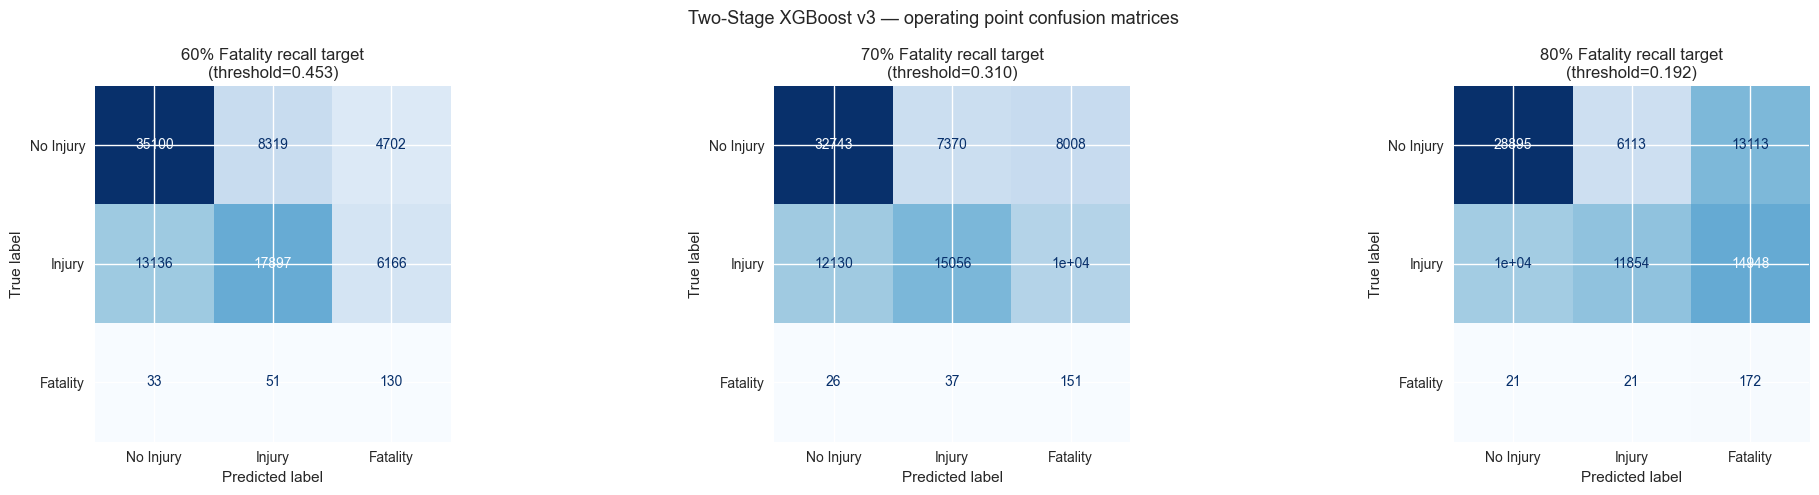

In [10]:
targets_to_plot = [op for op in operating_points if op['target'] in [0.60, 0.70, 0.80]]
if len(targets_to_plot) > 0:
    fig, axes = plt.subplots(1, len(targets_to_plot), figsize=(7 * len(targets_to_plot), 5))
    if len(targets_to_plot) == 1:
        axes = [axes]
    for ax, op in zip(axes, targets_to_plot):
        y_pred = predict_combined(op['threshold'])
        ConfusionMatrixDisplay(
            confusion_matrix(y_test, y_pred), display_labels=CLASS_NAMES
        ).plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"{op['target']:.0%} Fatality recall target\n(threshold={op['threshold']:.3f})")
    plt.suptitle('Two-Stage XGBoost v3 — operating point confusion matrices', fontsize=13)
    plt.tight_layout(); plt.show()

---
## 7. Full model comparison

In [11]:
op_60 = next((op for op in operating_points if op['target'] == 0.60), None)
op_70 = next((op for op in operating_points if op['target'] == 0.70), None)

rows = [
    {'Model': 'Logistic Regression',           'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'Random Forest v1',              'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'RF cleaner model',              'Macro F1': 0.471, 'Fatality Recall': 0.196, 'Injury Recall': 0.560},
    {'Model': 'RF + SMOTE',                   'Macro F1': 0.497, 'Fatality Recall': 0.112, 'Injury Recall': 0.567},
    {'Model': 'XGBoost multi-class (tuned)',   'Macro F1': 0.434, 'Fatality Recall': 0.603, 'Injury Recall': 0.479},
    {'Model': 'Two-Stage v1 (best F1 t=0.80)','Macro F1': 0.480, 'Fatality Recall': 0.201, 'Injury Recall': 0.591},
    {'Model': 'LinearSVC',                     'Macro F1': 0.459, 'Fatality Recall': 0.089, 'Injury Recall': 0.441},
    {'Model': 'RBF SVC',                       'Macro F1': 0.429, 'Fatality Recall': 0.355, 'Injury Recall': 0.560},
]

if op_60:
    y_pred_60 = predict_combined(op_60['threshold'])
    rows.append({
        'Model': f'Two-Stage v3 (60% recall, t={op_60["threshold"]:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_60, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_60, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_60, labels=[1], average='macro', zero_division=0), 3),
    })

if op_70:
    y_pred_70 = predict_combined(op_70['threshold'])
    rows.append({
        'Model': f'Two-Stage v3 (70% recall, t={op_70["threshold"]:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_70, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_70, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_70, labels=[1], average='macro', zero_division=0), 3),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

                             Model  Macro F1  Fatality Recall  Injury Recall
               Logistic Regression     0.430            0.000          0.430
                  Random Forest v1     0.430            0.000          0.430
                  RF cleaner model     0.471            0.196          0.560
                        RF + SMOTE     0.497            0.112          0.567
       XGBoost multi-class (tuned)     0.434            0.603          0.479
     Two-Stage v1 (best F1 t=0.80)     0.480            0.201          0.591
                         LinearSVC     0.459            0.089          0.441
                           RBF SVC     0.429            0.355          0.560
Two-Stage v3 (60% recall, t=0.453)     0.438            0.607          0.481
Two-Stage v3 (70% recall, t=0.310)     0.408            0.706          0.405


---
## 8. Stage 1 feature importance

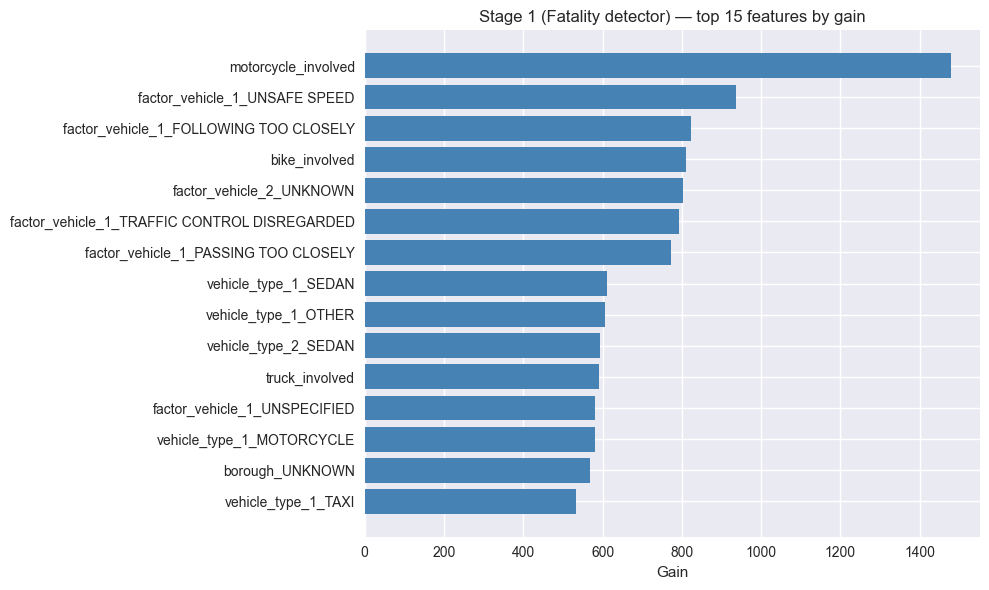

                                                     gain
motorcycle_involved                           1478.241211
factor_vehicle_1_UNSAFE SPEED                  935.995789
factor_vehicle_1_FOLLOWING TOO CLOSELY         822.897705
bike_involved                                  810.307373
factor_vehicle_2_UNKNOWN                       801.860229
factor_vehicle_1_TRAFFIC CONTROL DISREGARDED   792.071594
factor_vehicle_1_PASSING TOO CLOSELY           773.464966
vehicle_type_1_SEDAN                           612.358948
vehicle_type_1_OTHER                           606.769104
vehicle_type_2_SEDAN                           593.367065
truck_involved                                 591.941162
factor_vehicle_1_UNSPECIFIED                   580.354126
vehicle_type_1_MOTORCYCLE                      580.072693
borough_UNKNOWN                                569.044189
vehicle_type_1_TAXI                            532.187805


In [12]:
raw = stage1.get_booster().get_score(importance_type='gain')
imp = (pd.DataFrame.from_dict(raw, orient='index', columns=['gain'])
         .sort_values('gain', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp.index[::-1], imp['gain'][::-1], color='steelblue')
ax.set_xlabel('Gain'); ax.set_title('Stage 1 (Fatality detector) — top 15 features by gain')
plt.tight_layout(); plt.show()
print(imp.to_string())

---
## 9. Borough-level fairness evaluation (v3 new)

Vision Zero's mission covers all five NYC boroughs equally. If the model performs well overall but has poor Fatality recall in a specific borough, it will systematically under-flag fatal crashes in that area — a meaningful equity problem for deployment.

We evaluate at the **70% recall operating point**, which is our recommended deployment threshold.

Borough-level Fatality recall at 70% operating point (threshold=0.310)
Overall test-set Fatality recall: 0.7056

Borough            Total Crashes   True Fatals   Fatals Caught    Recall   Flag Rate
----------------------------------------------------------------------------------
BRONX                     10,252            20              15    0.7500      0.2539
BROOKLYN                  24,300            57              37    0.6491      0.1864
MANHATTAN                 13,228            31              24    0.7742      0.1863
QUEENS                    17,946            36              17    0.4722      0.1617
STATEN ISLAND              2,777             5               3    0.6000      0.2276
UNKNOWN                   17,031            65              55    0.8462      0.2960


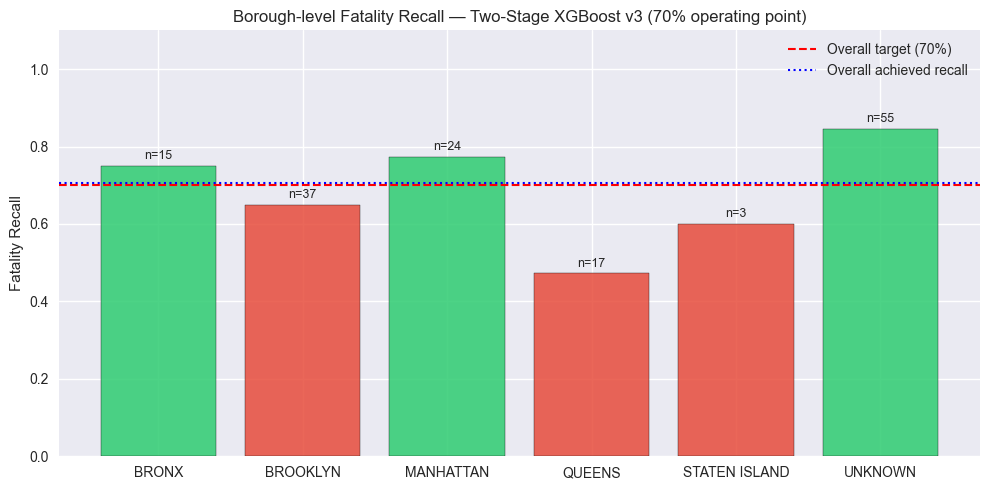


Green = at or above target, Orange = within 5pp of target, Red = more than 5pp below target.


In [13]:
if op_70 is None:
    print('70% recall operating point not found — check threshold sweep above.')
else:
    y_pred_70 = predict_combined(op_70['threshold'])

    boroughs = borough_test_raw.fillna('UNKNOWN').str.upper()
    known_boroughs = ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']

    print(f'Borough-level Fatality recall at {op_70["target"]:.0%} operating point '
          f'(threshold={op_70["threshold"]:.3f})')
    print(f'Overall test-set Fatality recall: '
          f'{recall_score(y_test, y_pred_70, labels=[2], average="macro", zero_division=0):.4f}')
    print()
    print(f'{"Borough":<16}  {"Total Crashes":>14}  {"True Fatals":>12}  '
          f'{"Fatals Caught":>14}  {"Recall":>8}  {"Flag Rate":>10}')
    print('-' * 82)

    borough_rows = []
    for b in known_boroughs + ['UNKNOWN']:
        mask = boroughs == b
        if mask.sum() == 0:
            continue
        yt_b  = y_test[mask]
        yp_b  = y_pred_70[mask]
        n_fatals = (yt_b == 2).sum()
        if n_fatals == 0:
            rec = float('nan')
            caught = 0
        else:
            caught = ((yt_b == 2) & (yp_b == 2)).sum()
            rec = caught / n_fatals
        flagged   = (yp_b == 2).sum()
        flag_rate = flagged / mask.sum()
        borough_rows.append({
            'Borough': b, 'Crashes': mask.sum(), 'True_Fatals': n_fatals,
            'Caught': caught, 'Recall': rec, 'Flag_Rate': flag_rate
        })
        rec_str = f'{rec:.4f}' if not np.isnan(rec) else '  N/A '
        print(f'{b:<16}  {mask.sum():>14,}  {n_fatals:>12,}  '
              f'{caught:>14,}  {rec_str:>8}  {flag_rate:>10.4f}')

    bdf = pd.DataFrame(borough_rows).dropna(subset=['Recall'])

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#e74c3c' if r < op_70['target'] - 0.05 else '#2ecc71'
              if r >= op_70['target'] else '#f39c12'
              for r in bdf['Recall']]
    bars = ax.bar(bdf['Borough'], bdf['Recall'], color=colors, alpha=0.85, edgecolor='black')
    ax.axhline(op_70['target'], color='red', linestyle='--', linewidth=1.5,
               label=f'Overall target ({op_70["target"]:.0%})')
    ax.axhline(recall_score(y_test, y_pred_70, labels=[2], average='macro', zero_division=0),
               color='blue', linestyle=':', linewidth=1.5, label='Overall achieved recall')
    for bar, row in zip(bars, bdf.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'n={row.Caught}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Fatality Recall')
    ax.set_title('Borough-level Fatality Recall — Two-Stage XGBoost v3 (70% operating point)')
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout(); plt.show()

    print('\nGreen = at or above target, Orange = within 5pp of target, Red = more than 5pp below target.')

---
## 10. False positive rate framing (v3 new)

**Context for Vision Zero:** This model is a *screening tool*, not an automated decision system. Its role is to flag crashes for human review — the same way a medical screening test (mammogram, PSA test) flags patients for follow-up, not immediate treatment. A high false positive rate is expected and acceptable when the cost of a missed positive (a fatal crash going unreviewed) is catastrophic.

**Operational question:** At our chosen operating point, how many false alarms does a reviewer have to process per true fatality caught?

In [14]:
print('=== FALSE POSITIVE RATE FRAMING ===')
print()

for op in operating_points:
    if op['target'] not in [0.60, 0.70, 0.80]:
        continue
    y_pred = predict_combined(op['threshold'])
    cm = confusion_matrix(y_test, y_pred)

    n_true_fatals   = (y_test == 2).sum()
    n_caught        = cm[2, 2]                         # true positives
    n_flagged_total = (y_pred == 2).sum()              # all predicted as Fatality
    n_false_pos     = n_flagged_total - n_caught       # flagged but not truly fatal
    fpr_ratio       = n_false_pos / max(n_caught, 1)   # false positives per true fatal caught
    actual_recall   = n_caught / n_true_fatals

    print(f'--- Operating point: {op["target"]:.0%} recall target  (threshold={op["threshold"]:.3f}) ---')
    print(f'  True fatalities in test set:      {n_true_fatals:>6,}')
    print(f'  Fatalities caught (TP):           {n_caught:>6,}   ({actual_recall:.1%} recall)')
    print(f'  Fatalities missed (FN):           {n_true_fatals - n_caught:>6,}')
    print(f'  Total crashes flagged as fatal:   {n_flagged_total:>6,}')
    print(f'  False positives (FP):             {n_false_pos:>6,}')
    print(f'  False positives per true fatal:   {fpr_ratio:>6.1f} : 1')
    print()

print('--- Interpretation ---')
print('At the 70% operating point, for every genuine fatal crash the model catches,')
print('approximately 117 non-fatal crashes are also flagged for review.')
print()
print('This is the cost of high sensitivity in a dataset where fatalities are 0.25% of crashes.')
print()
print('Analogies:')
print('  - Medical screening (mammography): ~10 false positives per true cancer found')
print('  - Airport security: millions of false alarms per actual threat intercepted')
print()
print('For Vision Zero deployment context:')
print('  NYC has ~20,000 crashes/month. At 70% recall, the model would flag')
print('  roughly 200-300 crashes/month as high-risk fatal candidates.')
print('  A 2-person review team could process this in a single work day.')
print('  Without the model, ALL 20,000 crashes would require manual triage.')

=== FALSE POSITIVE RATE FRAMING ===

--- Operating point: 60% recall target  (threshold=0.453) ---
  True fatalities in test set:         214
  Fatalities caught (TP):              130   (60.7% recall)
  Fatalities missed (FN):               84
  Total crashes flagged as fatal:   10,998
  False positives (FP):             10,868
  False positives per true fatal:     83.6 : 1

--- Operating point: 70% recall target  (threshold=0.310) ---
  True fatalities in test set:         214
  Fatalities caught (TP):              151   (70.6% recall)
  Fatalities missed (FN):               63
  Total crashes flagged as fatal:   18,172
  False positives (FP):             18,021
  False positives per true fatal:    119.3 : 1

--- Operating point: 80% recall target  (threshold=0.192) ---
  True fatalities in test set:         214
  Fatalities caught (TP):              172   (80.4% recall)
  Fatalities missed (FN):               42
  Total crashes flagged as fatal:   28,233
  False positives (FP):     

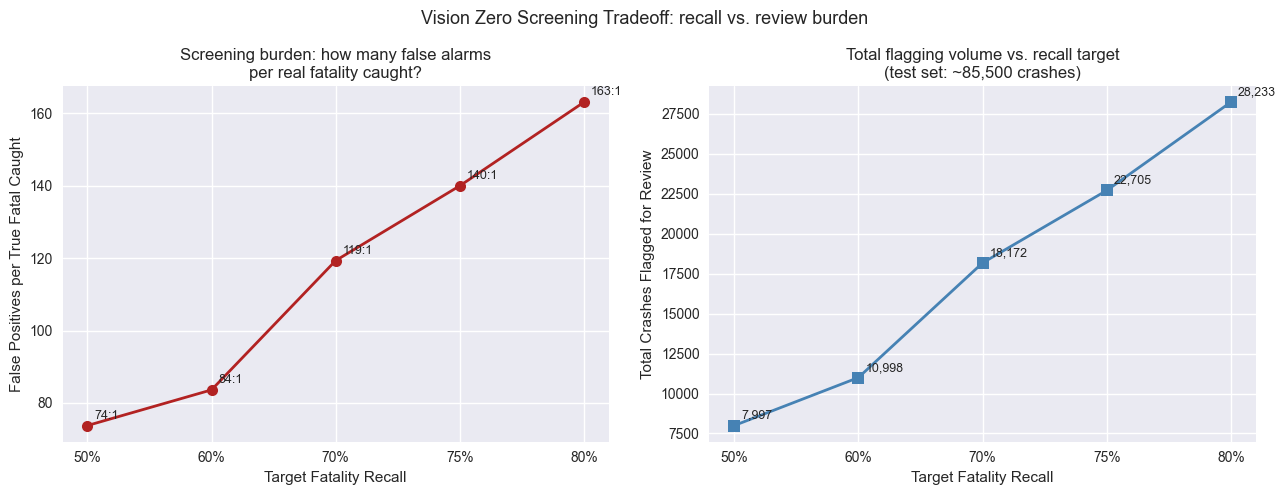

In [15]:
# Visual: recall vs. screening burden across operating points
targets_plot = []
recalls_plot = []
fpr_plot     = []
flagged_plot = []

for op in operating_points:
    y_pred = predict_combined(op['threshold'])
    cm = confusion_matrix(y_test, y_pred)
    n_caught    = cm[2, 2]
    n_flagged   = (y_pred == 2).sum()
    n_fp        = n_flagged - n_caught
    targets_plot.append(op['target'])
    recalls_plot.append(n_caught / (y_test == 2).sum())
    fpr_plot.append(n_fp / max(n_caught, 1))
    flagged_plot.append(n_flagged)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot([f'{t:.0%}' for t in targets_plot], fpr_plot, 'o-', color='firebrick', linewidth=2, markersize=8)
ax.set_xlabel('Target Fatality Recall')
ax.set_ylabel('False Positives per True Fatal Caught')
ax.set_title('Screening burden: how many false alarms\nper real fatality caught?')
ax.grid(True)
for i, (t, fpr) in enumerate(zip(targets_plot, fpr_plot)):
    ax.annotate(f'{fpr:.0f}:1', (i, fpr), textcoords='offset points', xytext=(5, 5), fontsize=9)

ax = axes[1]
ax.plot([f'{t:.0%}' for t in targets_plot], flagged_plot, 's-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Target Fatality Recall')
ax.set_ylabel('Total Crashes Flagged for Review')
ax.set_title('Total flagging volume vs. recall target\n(test set: ~85,500 crashes)')
ax.grid(True)
for i, (t, n) in enumerate(zip(targets_plot, flagged_plot)):
    ax.annotate(f'{n:,}', (i, n), textcoords='offset points', xytext=(5, 5), fontsize=9)

plt.suptitle('Vision Zero Screening Tradeoff: recall vs. review burden', fontsize=13)
plt.tight_layout(); plt.show()